In [1]:
import numpy as np
import os
import json
import time
import pandas as pd
from openai import OpenAI
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    hamming_loss,
    jaccard_score
)
from dotenv import load_dotenv

### Train set sampling

In [14]:
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
def load_and_preprocess_data(filepath, sample_size=400):
    try:
        # Read data
        df = pd.read_csv(filepath)

        # Simple cleaning: remove excessive whitespace or newlines
        df['comment_text'] = df['comment_text'].str.replace(r'\n', ' ', regex=True).str.strip()

        # Find all data with at least one label equal to 1 (i.e., toxic comments)
        toxic_rows = df[df[LABELS].sum(axis=1) > 0]
        # Find completely clean data
        clean_rows = df[df[LABELS].sum(axis=1) == 0]

        # Take half of each for testing
        n_toxic = sample_size // 2
        n_clean = sample_size - n_toxic

        df_toxic = toxic_rows.sample(n=n_toxic, random_state=42)
        df_clean = clean_rows.sample(n=n_clean, random_state=42)

        # Merge and shuffle the order
        df_balanced = pd.concat([df_toxic, df_clean]).sample(frac=1, random_state=42).reset_index(drop=True)

        return df_balanced

    except Exception as e:
        print(f"Error reading file: {e}")
        return None

# Execute loading
df_sample = load_and_preprocess_data('train.csv', sample_size=400)

### Zero shot prompt

In [15]:
def get_zero_shot_prompt(comment):
    prompt = f"""
Task: Analyze the following comment and select ALL applicable categories.

Categories:
- toxic: General rude, disrespectful, or unreasonable comment.
- severe_toxic: Extremely aggressive, hateful, or dangerous language.
- obscene: Use of swear words, profanity, or sexually explicit language.
- threat: Expresses an intention to cause physical harm or death.
- insult: Disrespectful term applied to a person or group.
- identity_hate: Hateful comments based on race, religion, gender, ethnicity, or sexual orientation.

Clarifications for Hard-to-Detect Labels:
- severe_toxic: Reserved for extreme malice, dehumanization, or wishing death. Heavy swearing alone is merely "obscene" or "toxic".
- identity_hate: MUST explicitly target a protected characteristic (race, religion, sexual orientation, etc.). A general personal attack is an "insult", not identity hate.
- threat: Requires a clear statement of INTENT to commit physical violence (e.g., "I will hurt you"). Merely wishing harm upon someone (e.g., "I hope you die") is "severe_toxic", NOT a threat.

Rules:
1. Evaluate the comment strictly against each definition and clarification.
2. Multiple categories can be selected.
3. If the comment is clean or just critical without being toxic, return an empty list.

Constraint:  Output strictly as a JSON object where keys are the category names and values are 1 if applicable and 0 otherwise.
Now classify the following comment:
Comment: "{comment}"

JSON Output:
"""
    return prompt

### Few shot prompt

In [16]:
def get_few_shot_prompt(comment):
    prompt = f"""
Task: Analyze the following comment and select ALL applicable categories.

Categories:
- toxic: General rude, disrespectful, or unreasonable comment.
- severe_toxic: Extremely aggressive, hateful, or dangerous language.
- obscene: Use of swear words, profanity, or sexually explicit language.
- threat: Expresses an intention to cause physical harm or death.
- insult: Disrespectful term applied to a person or group.
- identity_hate: Hateful comments based on race, religion, gender, ethnicity, or sexual orientation.

Clarifications for Hard-to-Detect Labels:
- severe_toxic: Reserved for extreme malice, dehumanization, or wishing death. Heavy swearing alone is merely "obscene" or "toxic".
- identity_hate: MUST explicitly target a protected characteristic (race, religion, sexual orientation, etc.). A general personal attack is an "insult", not identity hate.
- threat: Requires a clear statement of INTENT to commit physical violence (e.g., "I will hurt you"). Merely wishing harm upon someone (e.g., "I hope you die") is "severe_toxic", NOT a threat.

Rules:
1. Evaluate the comment strictly against each definition and clarification.
2. Multiple categories can be selected.
3. If the comment is clean or just critical without being toxic, return an empty list.

Example 1 (severe_toxic: sustained abusive language pattern):
Comment: "You're disgusting, worthless, and a complete waste. Shut up forever."
Output: {{"toxic": 1, "severe_toxic": 1, "obscene": 0, "threat": 0, "insult": 1, "identity_hate": 0}}

Example 2 (identity_hate: explicit protected group targeting):
Comment: "Muslims are disgusting and should be banned from this country."
Output: {{"toxic": 1, "severe_toxic": 1, "obscene": 0, "threat": 0, "insult": 0, "identity_hate": 1}}

Constraint: Output strictly as a JSON object where keys are the category names and values are 1 if applicable and 0 otherwise.
Now classify the following comment:
Comment: "{comment}"

JSON Output:
"""
    return prompt

### Model Operation Settings

In [2]:
# 1. API Settings and Model Initialization
def get_openai_api():
    # Explicitly specify the path to .env file
    load_dotenv(dotenv_path="API_KEY.env")
    API_KEY = os.getenv("API_KEY", "")
    return API_KEY

API_KEY = get_openai_api()

client = OpenAI(api_key=API_KEY)

# Select model
MODEL_NAME = "gpt-4o"

In [18]:
# 2. Call LLM for classification (with Retry, Backoff & Latency/Token tracking)

def get_llm_classification(comment, prompt_func, doc_id, max_retries=3):
    """
    Send comment to LLM, return JSON classification, token usage, latency, and retry counts.
    Includes Exponential Backoff for handling rate limits (e.g., Error 429).
    """
    prompt_content = prompt_func(comment)

    for attempt in range(1, max_retries + 1):
        start_time = time.time()
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": "You are a helpful assistant that classifies toxic comments. You always output valid JSON."},
                    {"role": "user", "content": prompt_content}
                ],
                # Enable JSON mode to ensure structured output
                response_format={"type": "json_object"},
                temperature=0
            )

            latency = time.time() - start_time
            result_text = response.choices[0].message.content
            result_json = json.loads(result_text)

            # Extract token usage for cost estimation
            prompt_tokens = response.usage.prompt_tokens if response.usage else 0
            completion_tokens = response.usage.completion_tokens if response.usage else 0

            return {
                "prediction": result_json,
                "latency": latency,
                "prompt_tokens": prompt_tokens,
                "completion_tokens": completion_tokens,
                "retry_count": attempt - 1,
                "status": "success"
            }

        except Exception as e:
            error_msg = str(e).lower()
            if "429" in error_msg or "rate limit" in error_msg:
                sleep_time = 2 ** attempt
                print(f"\n[Warning] Rate limit for id '{doc_id}'. Retrying in {sleep_time}s (Attempt {attempt}/{max_retries})...")
                time.sleep(sleep_time)
            else:
                sleep_time = 1.0
                print(f"\n[Warning] API call failed for id '{doc_id}': {e}. Retrying in {sleep_time}s (Attempt {attempt}/{max_retries})...")
                time.sleep(sleep_time)

    # Failsafe: return all zeros if all retries are exhausted
    print(f"\n[Error] Failed to get classification for id '{doc_id}' after {max_retries} attempts.")
    return {
        "prediction": {label: 0 for label in LABELS},
        "latency": time.time() - start_time,
        "prompt_tokens": 0,
        "completion_tokens": 0,
        "retry_count": max_retries,
        "status": "failed"
    }

In [22]:
# 3. Batch Processing (with Checkpoint/Resume & Cost Estimation)

def run_batch_classification(df, prompt_func, out_file_path, sleep_seconds=0.01, progress_every=20):
    print(f"\n[Info] Starting batch processing using model: {MODEL_NAME}")

    # Checkpoint loading: resume from where it stopped
    if os.path.exists(out_file_path):
        results_df = pd.read_csv(out_file_path)
        processed_ids = set(results_df["id"].astype(str).tolist())
        results = results_df.to_dict('records')
        print(f"[Info] Checkpoint found: '{out_file_path}'.")
        print(f"[Info] Loaded {len(processed_ids)} historical records. Skipping processed data...")
    else:
        processed_ids = set()
        results = []
        print(f"[Info] No checkpoint found. Starting fresh...")

    # Filter dataframe to exclude already processed records
    df_copy = df.copy()
    df_copy['id_str'] = df_copy['id'].astype(str)
    df_to_process = df_copy[~df_copy['id_str'].isin(processed_ids)]

    n_total = len(df)
    n_remain = len(df_to_process)

    print(f"[Info] Total records: {n_total} | Remaining to process: {n_remain} | Sleep_seconds: {sleep_seconds}s")

    if n_remain == 0:
        print("[Info] All records have been processed. Returning existing results.")
        return pd.DataFrame(results)

    start_time = time.time()
    total_prompt_tokens = 0
    total_completion_tokens = 0
    total_retries = 0
    latencies = []

    # Use itertuples instead of iterrows for faster iteration
    for i, row in enumerate(df_to_process.itertuples(index=False), start=1):
        comment = getattr(row, "comment_text")
        doc_id = getattr(row, "id")

        # Call LLM with retry logic
        response_data = get_llm_classification(comment, prompt_func, doc_id)
        prediction = response_data["prediction"]

        # Failsafe: unify predictions to 0/1 integers
        clean_prediction = {"id": doc_id}
        for label in LABELS:
            val = prediction.get(label, 0)
            if isinstance(val, bool):
                clean_prediction[label] = 1 if val else 0
            else:
                try:
                    clean_prediction[label] = int(val)
                except Exception:
                    clean_prediction[label] = 0

        # Append metadata tracking columns
        clean_prediction["prompt_tokens"] = response_data["prompt_tokens"]
        clean_prediction["completion_tokens"] = response_data["completion_tokens"]
        clean_prediction["latency_sec"] = round(response_data["latency"], 2)
        clean_prediction["retry_count"] = response_data["retry_count"]
        clean_prediction["status"] = response_data["status"]

        results.append(clean_prediction)

        # Accumulate statistics
        total_prompt_tokens += response_data["prompt_tokens"]
        total_completion_tokens += response_data["completion_tokens"]
        total_retries += response_data["retry_count"]
        latencies.append(response_data["latency"])

        # Progress update and checkpoint saving
        if progress_every and (i % progress_every == 0):
            avg_lat = sum(latencies[-progress_every:]) / progress_every if len(latencies) >= progress_every else sum(latencies) / len(latencies)
            print(f"[Progress] Processed {i}/{n_remain} records... (Avg Latency: {avg_lat:.2f}s/req)")
            pd.DataFrame(results).to_csv(out_file_path, index=False)

        if sleep_seconds > 0:
            time.sleep(sleep_seconds)

    # Final save upon completion
    pd.DataFrame(results).to_csv(out_file_path, index=False)

    total_time = time.time() - start_time
    avg_latency_overall = sum(latencies) / len(latencies) if latencies else 0

    # GPT-4o pricing approximation: $5.00 / 1M prompt tokens, $15.00 / 1M completion tokens
    cost_input = (total_prompt_tokens / 1_000_000) * 5.0
    cost_output = (total_completion_tokens / 1_000_000) * 15.0
    total_cost = cost_input + cost_output

    print(f"\n{'='*50}")
    print("Batch Processing Complete!")
    print(f"Total Time: {total_time:.2f} seconds")
    print(f"Avg Latency: {avg_latency_overall:.2f} seconds/req")
    print(f"Total Retries: {total_retries}")
    print(f"\n [Token Usage & Estimated Cost]")
    print(f"   - Prompt Tokens (Input): {total_prompt_tokens}")
    print(f"   - Completion Tokens (Output): {total_completion_tokens}")
    print(f"   - Total Tokens: {total_prompt_tokens + total_completion_tokens}")
    print(f"   - Estimated Cost: $ {total_cost:.4f} USD")
    print(f"     (Based on gpt-4o: $5/1M input, $15/1M output)")
    print(f"{'='*50}\n")

    return pd.DataFrame(results)

### Evaluation Function Encapsulation

In [20]:
def evaluate_predictions(df_true, df_pred, LABELS, title="Evaluation"):
    # Merge alignment
    df_evaluation = pd.merge(
        df_true[['id'] + LABELS],
        df_pred[['id'] + LABELS],
        on='id',
        how='inner',
        suffixes=('_true', '_pred')
    )

    # y_true / y_pred
    y_true = df_evaluation[[f"{l}_true" for l in LABELS]].values.astype(int)
    y_pred = df_evaluation[[f"{l}_pred" for l in LABELS]].values.astype(int)

    # Sanity check
    assert y_true.shape == y_pred.shape, f"Shape mismatch: {y_true.shape} vs {y_pred.shape}"
    assert set(np.unique(y_pred)).issubset({0,1}), f"y_pred contains non-binary values: {np.unique(y_pred)}"
    assert set(np.unique(y_true)).issubset({0,1}), f"y_true contains non-binary values: {np.unique(y_true)}"

    print("\n" + "="*40)
    print(title)
    print("="*40)

    subset_acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    macro_p = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_r = recall_score(y_true, y_pred, average='macro', zero_division=0)
    micro_p = precision_score(y_true, y_pred, average='micro', zero_division=0)
    micro_r = recall_score(y_true, y_pred, average='micro', zero_division=0)

    ham = hamming_loss(y_true, y_pred)

    print(f"Subset Accuracy (Exact Match): {subset_acc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Micro F1:    {micro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Macro Precision/Recall: {macro_p:.4f} / {macro_r:.4f}")
    print(f"Micro Precision/Recall: {micro_p:.4f} / {micro_r:.4f}")
    print(f"Hamming Loss: {ham:.4f}")

    print("\nDetailed classification metrics (per label):")
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))

    #  Return dictionary (necessary for comparison table later)
    return {
        "title": title,
        "subset_acc": subset_acc,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "weighted_f1": weighted_f1,
        "macro_p": macro_p,
        "macro_r": macro_r,
        "micro_p": micro_p,
        "micro_r": micro_r,
        "hamming_loss": ham
    }

### Train set testing and evaluation

In [24]:
if 'df_sample' in locals() and df_sample is not None:

    # 1) Run Zero-shot classification
    print(">>> Running Zero-shot ...")
    df_pred_zero = run_batch_classification(
        df_sample,
        get_zero_shot_prompt,
        out_file_path="train_zero_predictions.csv"
    )

    # 2) Run Few-shot classification
    print(">>> Running Few-shot ...")
    df_pred_few = run_batch_classification(
        df_sample,
        get_few_shot_prompt,
        out_file_path="train_few_predictions.csv"
    )

    # 3) Evaluate and Compare both methods
    zero_metrics = evaluate_predictions(df_sample, df_pred_zero, LABELS, title="Zero-shot Train Evaluation")
    few_metrics  = evaluate_predictions(df_sample, df_pred_few,  LABELS, title="Few-shot Train Evaluation")

    # Build comparison table
    df_compare = pd.DataFrame({
        "Zero-shot": pd.Series({k: v for k, v in zero_metrics.items() if k != "title"}),
        "Few-shot":  pd.Series({k: v for k, v in few_metrics.items()  if k != "title"})
    })

    # Calculate difference (Few-shot minus Zero-shot)
    df_compare["Δ (Few - Zero)"] = df_compare["Few-shot"] - df_compare["Zero-shot"]
    df_compare = df_compare.round(4)
    display(df_compare)

else:
    print("Error: 'df_sample' variable is None or not found. Please check your data loading steps (e.g., train.csv).")

>>> Running Zero-shot ...

[Info] Starting batch processing using model: gpt-4o
[Info] No checkpoint found. Starting fresh...
[Info] Total records: 400 | Remaining to process: 400 | Sleep_seconds: 0.01s
[Progress] Processed 20/400 records... (Avg Latency: 1.05s/req)
[Progress] Processed 40/400 records... (Avg Latency: 1.10s/req)
[Progress] Processed 60/400 records... (Avg Latency: 1.33s/req)
[Progress] Processed 80/400 records... (Avg Latency: 0.99s/req)
[Progress] Processed 100/400 records... (Avg Latency: 1.51s/req)
[Progress] Processed 120/400 records... (Avg Latency: 1.66s/req)
[Progress] Processed 140/400 records... (Avg Latency: 1.23s/req)
[Progress] Processed 160/400 records... (Avg Latency: 1.17s/req)
[Progress] Processed 180/400 records... (Avg Latency: 1.02s/req)
[Progress] Processed 200/400 records... (Avg Latency: 1.04s/req)
[Progress] Processed 220/400 records... (Avg Latency: 1.05s/req)
[Progress] Processed 240/400 records... (Avg Latency: 1.07s/req)
[Progress] Processed 

,Zero-shot,Few-shot,Δ (Few - Zero)
subset_acc,0.6125,0.6100,-0.0025
macro_f1,0.5638,0.6175,0.0537
micro_f1,0.7716,0.7767,0.0051
weighted_f1,0.7775,0.7891,0.0115
macro_p,0.5314,0.5739,0.0425
macro_r,0.6455,0.7056,0.0601
micro_p,0.7050,0.7044,-0.0006
micro_r,0.8520,0.8655,0.0135
hamming_loss,0.0938,0.0925,-0.0013


### Test set sampling: 3 seeds + storage

In [28]:
# 0) Settings
SEEDS = [42, 50, 88]
SAMPLE_N = 2000

# 1) Load full datasets
df_test = pd.read_csv("test.csv", encoding="latin-1", low_memory=False)
df_test_labels = pd.read_csv("test_labels.csv")

print("All test rows:", len(df_test))
print("All test label rows:", len(df_test_labels))

# 2) Clean labels: keep rows with NO -1 (all labels available)
mask = (df_test_labels[LABELS] != -1).all(axis=1)
df_test_labels_clean = df_test_labels[mask].copy()

print("Usable labels (non -1):", len(df_test_labels_clean))

# 3) Build clean test pool by id matching
df_test_clean = df_test[df_test['id'].isin(df_test_labels_clean['id'])].copy()

print("Usable test pool (matched by id):", len(df_test_clean))

# save the clean pool once
df_test_clean.to_csv("test_clean_pool.csv", index=False)
df_test_labels_clean.to_csv("test_labels_clean_pool.csv", index=False)

# 4) Sample 3 subsets WITHOUT replacement across runs
remaining = df_test_clean.copy()

for i, seed in enumerate(SEEDS, start=1):
    if len(remaining) < SAMPLE_N:
        raise ValueError(f"Not enough remaining rows to sample {SAMPLE_N}. Remaining: {len(remaining)}")

    df_sample_i = remaining.sample(n=SAMPLE_N, random_state=seed).copy()

    # save each sampled test subset
    test_out = f"test_sample_2000_clean_seed{seed}.csv"
    df_sample_i.to_csv(test_out, index=False)

    # also save the corresponding labels subset (for later evaluation)
    df_labels_i = df_test_labels_clean[df_test_labels_clean['id'].isin(df_sample_i['id'])].copy()
    labels_out = f"test_labels_sample_2000_clean_seed{seed}.csv"
    df_labels_i.to_csv(labels_out, index=False)

    print(f"[Seed {seed}] Saved: {test_out} ({len(df_sample_i)} rows), {labels_out} ({len(df_labels_i)} rows)")

    # remove sampled rows so next run is WITHOUT replacement
    remaining = remaining[~remaining['id'].isin(df_sample_i['id'])].copy()

print("Done. 3 disjoint samples saved.")

All test rows: 153164
All test label rows: 153164
Usable labels (non -1): 63978
Usable test pool (matched by id): 63978
[Seed 42] Saved: test_sample_2000_clean_seed42.csv (2000 rows), test_labels_sample_2000_clean_seed42.csv (2000 rows)
[Seed 50] Saved: test_sample_2000_clean_seed50.csv (2000 rows), test_labels_sample_2000_clean_seed50.csv (2000 rows)
[Seed 88] Saved: test_sample_2000_clean_seed88.csv (2000 rows), test_labels_sample_2000_clean_seed88.csv (2000 rows)
Done. 3 disjoint samples saved.


### Test set: zero-shot prompt

In [29]:
for seed in SEEDS:
    df_test_sample = pd.read_csv(f"test_sample_2000_clean_seed{seed}.csv")
    out_path = f"zero_test_predictions_seed{seed}.csv"

    df_pred_zero = run_batch_classification(
        df_test_sample,
        get_zero_shot_prompt,
        out_file_path=out_path
    )

    print(f"[Zero-shot] Seed {seed} saved/verified -> {out_path} | rows={len(df_pred_zero)}")


[Info] Starting batch processing using model: gpt-4o
[Info] No checkpoint found. Starting fresh...
[Info] Total records: 2000 | Remaining to process: 2000 | Sleep_seconds: 0.01s
[Progress] Processed 20/2000 records... (Avg Latency: 0.99s/req)
[Progress] Processed 40/2000 records... (Avg Latency: 0.97s/req)
[Progress] Processed 60/2000 records... (Avg Latency: 1.11s/req)
[Progress] Processed 80/2000 records... (Avg Latency: 0.92s/req)
[Progress] Processed 100/2000 records... (Avg Latency: 0.96s/req)
[Progress] Processed 120/2000 records... (Avg Latency: 0.80s/req)
[Progress] Processed 140/2000 records... (Avg Latency: 0.93s/req)
[Progress] Processed 160/2000 records... (Avg Latency: 1.03s/req)
[Progress] Processed 180/2000 records... (Avg Latency: 0.98s/req)
[Progress] Processed 200/2000 records... (Avg Latency: 0.92s/req)
[Progress] Processed 220/2000 records... (Avg Latency: 1.11s/req)
[Progress] Processed 240/2000 records... (Avg Latency: 1.09s/req)
[Progress] Processed 260/2000 rec

### Test set: few-shot prompt

In [30]:
for seed in SEEDS:
    df_test_sample = pd.read_csv(f"test_sample_2000_clean_seed{seed}.csv")
    out_path = f"few_test_predictions_seed{seed}.csv"

    df_pred_few = run_batch_classification(
        df_test_sample,
        get_few_shot_prompt,
        out_file_path=out_path
    )

    print(f"[Few-shot] Seed {seed} saved/verified -> {out_path} | rows={len(df_pred_few)}")


[Info] Starting batch processing using model: gpt-4o
[Info] No checkpoint found. Starting fresh...
[Info] Total records: 2000 | Remaining to process: 2000 | Sleep_seconds: 0.01s
[Progress] Processed 20/2000 records... (Avg Latency: 0.82s/req)
[Progress] Processed 40/2000 records... (Avg Latency: 0.71s/req)
[Progress] Processed 60/2000 records... (Avg Latency: 1.01s/req)
[Progress] Processed 80/2000 records... (Avg Latency: 0.92s/req)
[Progress] Processed 100/2000 records... (Avg Latency: 1.00s/req)
[Progress] Processed 120/2000 records... (Avg Latency: 0.90s/req)
[Progress] Processed 140/2000 records... (Avg Latency: 0.77s/req)
[Progress] Processed 160/2000 records... (Avg Latency: 0.69s/req)
[Progress] Processed 180/2000 records... (Avg Latency: 0.74s/req)
[Progress] Processed 200/2000 records... (Avg Latency: 0.78s/req)
[Progress] Processed 220/2000 records... (Avg Latency: 0.80s/req)
[Progress] Processed 240/2000 records... (Avg Latency: 0.98s/req)
[Progress] Processed 260/2000 rec

### Zero & few shots evaluation

In [31]:
results_all = {}
for prompt_name, pred_file in [("zero", "zero_test_predictions"), ("few", "few_test_predictions")]:
    metrics_all = {}
    for seed in SEEDS:
        df_true = pd.read_csv(f"test_labels_sample_2000_clean_seed{seed}.csv")
        df_pred = pd.read_csv(f"{pred_file}_seed{seed}.csv")
        df_pred_clean = df_pred[df_pred['id'].isin(df_true['id'])].copy()
        metrics_all[seed] = evaluate_predictions(df_true, df_pred_clean, LABELS,
                                                  title=f"{prompt_name}-shot (seed={seed})")
    results_all[prompt_name] = metrics_all


zero-shot (seed=42)
Subset Accuracy (Exact Match): 0.8210
Macro F1:    0.5189
Micro F1:    0.5389
Weighted F1: 0.5447
Macro Precision/Recall: 0.4049 / 0.7420
Micro Precision/Recall: 0.4116 / 0.7805
Hamming Loss: 0.0548

Detailed classification metrics (per label):
               precision    recall  f1-score   support

        toxic       0.44      0.81      0.57       201
 severe_toxic       0.38      0.62      0.47        13
      obscene       0.51      0.73      0.60       123
       threat       0.45      0.71      0.56         7
       insult       0.35      0.80      0.48       121
identity_hate       0.30      0.78      0.44        27

    micro avg       0.41      0.78      0.54       492
    macro avg       0.40      0.74      0.52       492
 weighted avg       0.42      0.78      0.54       492
  samples avg       0.07      0.08      0.07       492


zero-shot (seed=50)
Subset Accuracy (Exact Match): 0.8205
Macro F1:    0.5330
Micro F1:    0.5558
Weighted F1: 0.5628
Macro P

### Average result for three seeds: comparison

In [32]:
# 1) Modified metric calculation function
def compute_metrics(df_true, df_pred, labels):
    df_merged = pd.merge(
        df_true[['id'] + labels],
        df_pred[['id'] + labels],
        on='id',
        suffixes=('_true', '_pred')
    )

    # Extract aligned matrix
    y_true = df_merged[[f"{l}_true" for l in labels]].values.astype(int)
    y_pred = df_merged[[f"{l}_pred" for l in labels]].values.astype(int)

    # Calculate the full set of metrics consistent with the screenshot
    return {
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
    }

# 2) Loop to collect results for 3 seeds
zero_results = []
few_results = []

for seed in SEEDS:
    # Load data
    df_true = pd.read_csv(f"test_labels_sample_2000_clean_seed{seed}.csv")
    df_zero = pd.read_csv(f"zero_test_predictions_seed{seed}.csv")
    df_few  = pd.read_csv(f"few_test_predictions_seed{seed}.csv")

    # Calculate and append
    zero_results.append(compute_metrics(df_true, df_zero, LABELS))
    few_results.append(compute_metrics(df_true, df_few, LABELS))

# 3) Calculate average and build comparison table
# Convert list to DataFrame and take the mean
df_zero_avg = pd.DataFrame(zero_results).mean()
df_few_avg  = pd.DataFrame(few_results).mean()

comparison_table = pd.DataFrame({
    "Zero-shot": df_zero_avg,
    "Few-shot": df_few_avg
})

# Calculate difference (Few - Zero)
comparison_table["Δ (Few - Zero)"] = comparison_table["Few-shot"] - comparison_table["Zero-shot"]

# Format output
comparison_table = comparison_table.round(4)

print("\n===== Averaged Evaluation Results (Across 3 Seeds) =====\n")
display(comparison_table)


===== Averaged Evaluation Results (Across 3 Seeds) =====



,Zero-shot,Few-shot,Δ (Few - Zero)
Subset Accuracy,0.8267,0.8300,0.0033
Macro F1,0.5147,0.5249,0.0102
Micro F1,0.5478,0.5493,0.0015
Weighted F1,0.5535,0.5567,0.0032
Macro Precision,0.4244,0.4239,-0.0006
Macro Recall,0.7018,0.7348,0.0331
Micro Precision,0.4245,0.4239,-0.0006
Micro Recall,0.7732,0.7810,0.0078
Hamming Loss,0.0509,0.0511,0.0002


In [34]:
# 1) Define function to extract metrics by label
def get_per_label_metrics(df_true, df_pred, labels):
    # Force ID alignment
    df_merged = pd.merge(
        df_true[['id'] + labels],
        df_pred[['id'] + labels],
        on='id',
        suffixes=('_true', '_pred')
    )

    y_true = df_merged[[f"{l}_true" for l in labels]].values.astype(int)
    y_pred = df_merged[[f"{l}_pred" for l in labels]].values.astype(int)

    # Calculate P, R, F1 for each label
    # average=None will return an array, order consistent with labels list
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    return pd.DataFrame({
        "Precision": p,
        "Recall": r,
        "F1": f1
    }, index=labels)

# 2) Loop to calculate data for all seeds
zero_label_results = []
few_label_results = []

for seed in SEEDS:
    df_true = pd.read_csv(f"test_labels_sample_2000_clean_seed{seed}.csv")
    df_zero = pd.read_csv(f"zero_test_predictions_seed{seed}.csv")
    df_few  = pd.read_csv(f"few_test_predictions_seed{seed}.csv")

    zero_label_results.append(get_per_label_metrics(df_true, df_zero, LABELS))
    few_label_results.append(get_per_label_metrics(df_true, df_few, LABELS))

# 3) Calculate mean (Mean over Seeds)
# Average by grouping by index after concat
df_zero_label_avg = pd.concat(zero_label_results).groupby(level=0).mean()
df_few_label_avg  = pd.concat(few_label_results).groupby(level=0).mean()

# 4) Format output for three comparison tables
metrics = ["Precision", "Recall", "F1"]
tables = {}

for m in metrics:
    tab = pd.DataFrame({
        f"Zero-shot {m}": df_zero_label_avg[m],
        f"Few-shot {m}": df_few_label_avg[m]
    })
    tab["Improvement"] = tab[f"Few-shot {m}"] - tab[f"Zero-shot {m}"]
    tables[m] = tab.round(4)

# Print results
print("--- [Table 1: Label Precision Comparison] ---")
display(tables["Precision"])

print("\n--- [Table 2: Label Recall Comparison] ---")
display(tables["Recall"])

print("\n--- [Table 3: Label F1-score Comparison] ---")
display(tables["F1"])

--- [Table 1: Label Precision Comparison] ---


,Zero-shot Precision,Few-shot Precision,Improvement
identity_hate,0.3398,0.3411,0.0013
insult,0.3446,0.3484,0.0039
obscene,0.5078,0.5095,0.0017
severe_toxic,0.2495,0.2032,-0.0463
threat,0.6414,0.6797,0.0382
toxic,0.4636,0.4611,-0.0024



--- [Table 2: Label Recall Comparison] ---


,Zero-shot Recall,Few-shot Recall,Improvement
identity_hate,0.8009,0.7906,-0.0104
insult,0.8076,0.7866,-0.0211
obscene,0.7390,0.7731,0.0340
severe_toxic,0.3819,0.4913,0.1094
threat,0.6825,0.7672,0.0847
toxic,0.7986,0.8004,0.0018



--- [Table 3: Label F1-score Comparison] ---


,Zero-shot F1,Few-shot F1,Improvement
identity_hate,0.4751,0.4756,0.0006
insult,0.4827,0.4827,-0.0000
obscene,0.6018,0.6140,0.0122
severe_toxic,0.3016,0.2866,-0.0150
threat,0.6407,0.7056,0.0648
toxic,0.5860,0.5847,-0.0013


### Error case analysis

In [35]:
# Step 1: Merge prediction results from all seeds + true labels + original texts
all_frames = []

for seed in SEEDS:
    df_true    = pd.read_csv(f"test_labels_sample_2000_clean_seed{seed}.csv")
    df_pred    = pd.read_csv(f"few_test_predictions_seed{seed}.csv")
    df_text    = pd.read_csv(f"test_sample_2000_clean_seed{seed}.csv")  # Original text

    df = pd.merge(df_true[['id'] + LABELS], df_pred[['id'] + LABELS], on='id', suffixes=('_true', '_pred'))
    df = pd.merge(df, df_text[['id', 'comment_text']], on='id')
    df['seed'] = seed
    all_frames.append(df)

df_all = pd.concat(all_frames, ignore_index=True)
print(f"Total rows: {len(df_all)}")

Total rows: 6000


In [36]:
# Step 2: Mark error types for each sample × each label
#   TP / FP / FN / TN
error_rows = []

for _, row in df_all.iterrows():
    for label in LABELS:
        true_val = int(row[f"{label}_true"])
        pred_val = int(row[f"{label}_pred"])

        if true_val == 1 and pred_val == 0:
            error_type = "FN"   # False Negative: Model failed to identify
        elif true_val == 0 and pred_val == 1:
            error_type = "FP"   # False Positive: Model over-predicted
        elif true_val == 1 and pred_val == 1:
            error_type = "TP"
        else:
            error_type = "TN"

        error_rows.append({
            "id": row["id"],
            "seed": row["seed"],
            "label": label,
            "true": true_val,
            "pred": pred_val,
            "error_type": error_type,
            "comment_text": row["comment_text"]
        })

df_errors = pd.DataFrame(error_rows)
print(df_errors["error_type"].value_counts())

error_type
TN    33039
FP     1527
TP     1121
FN      313
Name: count, dtype: int64



=== FP / FN Count per Label (Across All Seeds) ===


error_type,FN,FP
label,,
toxic,120,566
severe_toxic,18,67
obscene,81,263
threat,6,10
insult,73,508
identity_hate,15,113


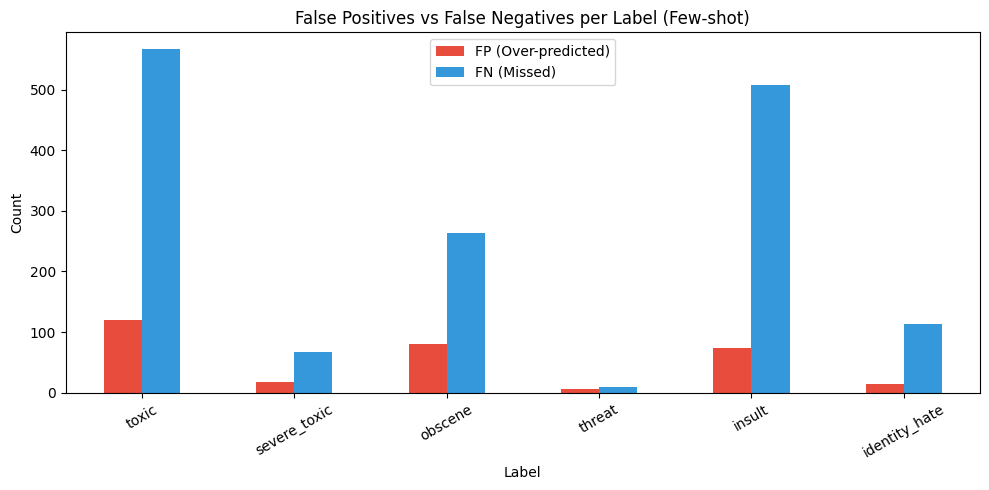

In [37]:
# Step 3: FP / FN count statistics for each label (Visualization)
df_fp_fn = df_errors[df_errors["error_type"].isin(["FP", "FN"])]

pivot = df_fp_fn.groupby(["label", "error_type"]).size().unstack(fill_value=0)
pivot = pivot.reindex(LABELS)  # Keep fixed order

print("\n=== FP / FN Count per Label (Across All Seeds) ===")
display(pivot)

# Bar chart
pivot.plot(kind="bar", figsize=(10, 5), color=["#e74c3c", "#3498db"])
plt.title("False Positives vs False Negatives per Label (Few-shot)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(["FP (Over-predicted)", "FN (Missed)"])
plt.tight_layout()
plt.show()

In [38]:
def show_error_cases(label, error_type="FN", n=10):
    subset = df_errors[
        (df_errors["label"] == label) &
        (df_errors["error_type"] == error_type)
    ].drop_duplicates("id").head(n)

    print(f"\n{'='*60}")
    print(f"  [{error_type}] Label: {label}  |  Total {len(subset)} samples (showing top {n})")
    print(f"{'='*60}")
    for i, row in subset.iterrows():
        print(f"\n[#{i}] seed={row['seed']} | true={row['true']} | pred={row['pred']}")
        print(f"  Comment: {row['comment_text'][:300]}")
    print()

# Step 5: View False Positives (FP) — samples over-classified by the model
for label in LABELS:
    show_error_cases(label, error_type="FP", n=5)


  [FP] Label: toxic  |  Total 5 samples (showing top 5)

[#132] seed=42 | true=0 | pred=1
  Comment: I HOPE YOU GET THE SWINE FLU 

 WALLAH BRO 

 MOVE OUT OF UR MOMS BASEMENT

[#138] seed=42 | true=0 | pred=1
  Comment: So you support someone to calling stupid between registered editor?. Very nice to know, and please do not give me a warning again, because you don't deserve doing that.

[#156] seed=42 | true=0 | pred=1
  Comment: " 
 ::::I'm not sure what could be more representative of Islam. Maybe this photo?  '''''' "

[#240] seed=42 | true=0 | pred=1
  Comment: Hitler was blates jewish.

[#276] seed=42 | true=0 | pred=1
  Comment: ==A light bit of vandalism== 
 I didn't want to put npov text in the article, so this shall go here: 
 :I hate this whore, and everything that she stands for. 
 Now back to your regularly scheduled wikipediaing.  |  |


  [FP] Label: severe_toxic  |  Total 5 samples (showing top 5)

[#337] seed=42 | true=0 | pred=1
  Comment: == This man is scum == 

 H

In [39]:
# Step 6: Co-occurrence error analysis — Which label combinations often fail together?
# Extract errors at the whole sample level: at least one label error
df_sample_errors = df_all.copy()
for label in LABELS:
    df_sample_errors[f"{label}_FP"] = (
        (df_sample_errors[f"{label}_true"] == 0) &
        (df_sample_errors[f"{label}_pred"] == 1)
    ).astype(int)
    df_sample_errors[f"{label}_FN"] = (
        (df_sample_errors[f"{label}_true"] == 1) &
        (df_sample_errors[f"{label}_pred"] == 0)
    ).astype(int)

# Total errors
df_sample_errors["n_errors"] = df_sample_errors[
    [f"{l}_FP" for l in LABELS] + [f"{l}_FN" for l in LABELS]
].sum(axis=1)

# Add: number of FP, number of FN, FP labels list, FN labels list
df_sample_errors["n_FP"] = df_sample_errors[[f"{l}_FP" for l in LABELS]].sum(axis=1)
df_sample_errors["n_FN"] = df_sample_errors[[f"{l}_FN" for l in LABELS]].sum(axis=1)
df_sample_errors["FP_labels"] = df_sample_errors.apply(
    lambda row: [l for l in LABELS if row[f"{l}_FP"] == 1], axis=1
)
df_sample_errors["FN_labels"] = df_sample_errors.apply(
    lambda row: [l for l in LABELS if row[f"{l}_FN"] == 1], axis=1
)

# Show samples with the most errors
worst_cases = df_sample_errors[df_sample_errors["n_errors"] >= 2].sort_values("n_errors", ascending=False)
print(f"\nNumber of samples with multiple label errors simultaneously: {len(worst_cases)}")
display(worst_cases[["comment_text", "n_errors", "n_FP", "n_FN", "FP_labels", "FN_labels"]].head(10))


Number of samples with multiple label errors simultaneously: 639


,comment_text,n_errors,n_FP,n_FN,FP_labels,FN_labels
1765,""" \n Bonaparte, he might have made a good cont...",6,6,0,"[toxic, severe_toxic, obscene, threat, insult,...",[]
352,== world Peace == \n\n Look every one there sa...,5,5,0,"[toxic, severe_toxic, obscene, insult, identit...",[]
1745,. The next time a towelhead tries to threaten ...,5,5,0,"[toxic, severe_toxic, threat, insult, identity...",[]
4329,": Lovely, the resistance is increasing, after ...",4,4,0,"[toxic, severe_toxic, insult, identity_hate]",[]
5432,== I deleted the axelrod insult. == \n\n and I...,4,4,0,"[toxic, obscene, insult, identity_hate]",[]
2997,ok ur gay ha ha ahhhhhhhhhhh ah ha ha wer u go...,4,1,3,[severe_toxic],"[obscene, threat, identity_hate]"
2538,::i welcome rs views of the tea party good or ...,4,4,0,"[toxic, obscene, insult, identity_hate]",[]
2382,==Delete Request== \n Someone hacked my accoun...,4,4,0,"[toxic, obscene, insult, identity_hate]",[]
2147,""" \n\n == More of Comanche's vandalism == \n\n...",4,4,0,"[toxic, obscene, insult, identity_hate]",[]
2052,== Administration == \n\n Admins sind die GrÃ¶...,4,4,0,"[toxic, obscene, insult, identity_hate]",[]


In [40]:
# Step 7: Error rate summary table (by label)
summary = []
for label in LABELS:
    sub = df_errors[df_errors["label"] == label]
    total_pos = (sub["true"] == 1).sum()
    total_neg = (sub["true"] == 0).sum()
    fp = (sub["error_type"] == "FP").sum()
    fn = (sub["error_type"] == "FN").sum()
    summary.append({
        "Label": label,
        "Total Positive": total_pos,
        "Total Negative": total_neg,
        "FP (False Positive)": fp,
        "FN (False Negative)": fn,
        "FP Rate": round(fp / total_neg, 4) if total_neg > 0 else 0,
        "FN Rate (Miss Rate)": round(fn / total_pos, 4) if total_pos > 0 else 0,
    })

df_summary = pd.DataFrame(summary).set_index("Label")
print("\n=== Error Rate Summary ===")
display(df_summary)


=== Error Rate Summary ===


,Total Positive,Total Negative,FP (False Positive),FN (False Negative),FP Rate,FN Rate (Miss Rate)
Label,,,,,,
toxic,603,5397,566,120,0.1049,0.1990
severe_toxic,36,5964,67,18,0.0112,0.5000
obscene,354,5646,263,81,0.0466,0.2288
threat,25,5975,10,6,0.0017,0.2400
insult,344,5656,508,73,0.0898,0.2122
identity_hate,72,5928,113,15,0.0191,0.2083
